# Dataset Filtering & Quality Analysis
**Goal:** Extract a small, high-quality, realistic subset from the Tobi dataset.

Pipeline:
1. Load raw Tobi dataset
2. Language + merge filter (same as v5)
3. Hard quality filters (label coherence, template detection, length)
4. Soft quality scoring (specificity, human markers, content density)
5. Priority relabelling from signal rules
6. Class balancing
7. Train / val / test split
8. Full visual analysis of what survived

## 0. Imports

In [16]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

DEPT_ORDER = [
    'Billing and Payments',
    'Customer Service',
    'General Inquiry',
    'Human Resources',
    'Returns and Exchanges',
    'Sales and Pre-Sales',
    'Service Outages and Maintenance',
    'Technical & IT Support',
]
PRIORITY_ORDER = ['high', 'medium', 'low']
PALETTE_DEPT = sns.color_palette('tab10', len(DEPT_ORDER))
PALETTE_PRI  = {'high': '#e05c5c', 'medium': '#f0a500', 'low': '#5ca85c'}

print('Imports OK')

Imports OK


## 1. Load Raw Dataset

In [17]:
ds = load_dataset('Tobi-Bueck/customer-support-tickets')
df_raw = ds['train'].to_pandas()

print(f'Total rows (all languages): {len(df_raw):,}')
print(f'\nLanguage distribution:')
print(df_raw['language'].value_counts())

Total rows (all languages): 61,765

Language distribution:
language
de    33504
en    28261
Name: count, dtype: int64


## 2. Base Preprocessing (same as v5)

In [18]:
# English only
df = df_raw[df_raw['language'] == 'en'].copy()
print(f'English only: {len(df):,}')

# Merge technical classes
merge_classes = ['IT Support', 'Technical Support', 'Product Support']
df['queue'] = df['queue'].replace(merge_classes, 'Technical & IT Support')

# ── Extract CUSTOMER message only (not agent reply) ───────────────────
# Tobi body = <customer message>\n<agent reply>
# Agent replies start with recognisable patterns — stop before them.

AGENT_MARKERS = [
    r'^thank you for (reaching out|contacting|your (message|email|inquiry))',
    r'^we (understand|appreciate|have received|are sorry|apologize|recommend|suggest|advise)',
    r'^we\'re (sorry|happy|glad|pleased) to hear',
    r'^i\'m (sorry|happy|glad|pleased) to hear',
    r'^hello\s+\w+[,.]',
    r'^hi\s+\w+[,.]',
    r'^our (team|support team|technical team)',
    r'^could you (please\s+)?(provide|share|confirm|specify|offer|clarify|advise)',
    r'^to (assist|help) you (further|better)',
    r'^please (ensure|make sure|verify|check|confirm|note)',
    r'^we (recommend|suggest|would like to|will)',
    r'^i (recommend|suggest|would like to|will look into)',
    r'^as (requested|discussed|mentioned)',
    r'^regarding your (inquiry|request|issue|ticket)',
]

def extract_customer_message(body):
    if not isinstance(body, str) or not body.strip():
        return ''
    # Normalise literal \n sequences to real newlines
    text = body.replace('\\n', '\n')
    paragraphs = [p.strip() for p in text.split('\n') if p.strip()]
    customer_paragraphs = []
    for para in paragraphs:
        is_agent = any(re.match(m, para, re.IGNORECASE) for m in AGENT_MARKERS)
        if is_agent:
            break
        customer_paragraphs.append(para)
    result = ' '.join(customer_paragraphs).strip()
    # Fallback: if nothing survived, return full body (better than empty)
    return result if len(result.split()) >= 5 else ' '.join(paragraphs)

df['text'] = df['body'].fillna('').apply(extract_customer_message)

# ── Clean the extracted customer text ─────────────────────────────────
def clean_text_basic(text):
    text = str(text)

    # Strip HTML
    text = re.sub(r'<[^>]+>', ' ', text)

    # Normalise any remaining literal \n
    text = text.replace('\\n', ' ')

    # Strip salutations — anchor to start to avoid eating into content words
    # Pattern: greeting word + up to 50 chars + punctuation boundary
    text = re.sub(
        r'^(dear|hello|hi|respected|greetings)[^\n,.:!?]{0,50}[,:\-]\s*',
        '', text, flags=re.IGNORECASE
    )
    # Also strip standalone "Customer Support," or "Support Team," mid-text
    text = re.sub(
        r'\b(customer\s+support|support\s+team|dear\s+customer\s+support'
        r'|dear\s+support\s+team|to\s+whom\s+it\s+may\s+concern)[,:\-]?\s*',
        '', text, flags=re.IGNORECASE
    )

    # Strip "I hope this message finds you well"
    text = re.sub(
        r'i\s+hope\s+this\s+(message|email)\s+(finds|reaches)\s+you\s+well[.,]?',
        '', text, flags=re.IGNORECASE
    )

    # Strip "I am writing/contacting/reaching out to..."
    text = re.sub(
        r'i\s+am\s+(writing|contacting|reaching\s+out)\s+to[^.]*\.',
        '', text, flags=re.IGNORECASE
    )

    # Strip closings
    text = re.sub(
        r'(best\s+regards|sincerely|kind\s+regards|warm\s+regards'
        r'|thank\s+you\s+for\s+your|i\s+look\s+forward\s+to'
        r'|i\s+would\s+greatly\s+appreciate|i\s+appreciate\s+your'
        r'|please\s+do\s+not\s+hesitate|feel\s+free\s+to\s+(contact|reach))[^.]*[.,]?',
        '', text, flags=re.IGNORECASE
    )

    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text'] = df['text'].apply(clean_text_basic)
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Normalise priority to lowercase
df['priority'] = df['priority'].str.lower().str.strip()

# ── Sanity check ──────────────────────────────────────────────────────
print("Sample extracted customer messages (check for agent text / fragments):")
for _, row in df.sample(5, random_state=42).iterrows():
    print(f"  [{row['queue']}] {row['text'][:200]!r}")
    print()

print(f'\nQueue distribution (raw English):')
print(df['queue'].value_counts())
print(f'\nPriority distribution (raw English):')
print(df['priority'].value_counts())


English only: 28,261
Sample extracted customer messages (check for agent text / fragments):
  [Technical & IT Support] 'Please request an update to the integration settings to ensure compatibility with various devices for the software project management workflows, to guarantee seamless operations.'

  [Technical & IT Support] 'Insufficient encryption led to the data breach problem'

  [Customer Service] 'The analytics data for the website have indicated a notable decrease in traffic last week. This could be due to recent algorithm changes or technical issues. Despite efforts to update SEO strategies a'

  [Technical & IT Support] 'I am currently encountering integration problems with CyberLink PowerDirector 19, DaVinci Resolve 17, and Asana following the recent update.'

  [Customer Service] 'I am interested in understanding how Alteryx can improve our data analytics for investment optimization. Could you provide detailed information on the features and tools that Alteryx offers to sup

## 3. Filter Functions

In [19]:
# ── 3a. HARD FILTER: template skeleton detection ───────────────────────────

SYNTHETIC_RED_FLAGS = [
    r'i am writing to (inform|report|request|inquire|bring)',
    r'i am contacting you (today )?regarding',
    r'i am reaching out to',
    r'this is to (inform|notify) you',
    r'i would like to bring to your attention',
    r'please (advise|do not hesitate to contact)',
    r'at your earliest convenience',
    r'i look forward to your (prompt )?response',
    r'thank you for your (assistance|understanding|prompt)',
    r'best regards|sincerely yours|kind regards|warm regards',
    r'dear (customer support|support team|sir[/\\]?madam)',
    r'i hope this (message|email) finds you well',
    r'i wanted to (reach out|contact you)',
    r'please feel free to (contact|reach out)',
    r'i appreciate your (help|assistance|time)',
]

def template_hit_count(text: str) -> int:
    return sum(
        1 for p in SYNTHETIC_RED_FLAGS
        if re.search(p, text, re.IGNORECASE)
    )

def is_template_skeleton(text: str) -> bool:
    """True = drop this ticket (too templated)."""
    return template_hit_count(text) >= 2


# ── 3b. HARD FILTER: label coherence ──────────────────────────────────────

DEPT_ANCHORS = {
    'Billing and Payments': [
        'invoice', 'charge', 'payment', 'refund', 'subscription', 'fee',
        'billing', 'charged', 'receipt', 'overcharged', 'amount', 'transaction',
        'credit card', 'debit', 'bank', 'statement', 'duplicate charge',
        'bill', 'cost', 'price', 'paid', 'autopay', 'renewal',
    ],
    'Technical & IT Support': [
        'error', 'crash', 'bug', 'not working', 'server', 'login', 'password',
        'software', 'system', 'portal', 'access denied', 'timeout', 'freeze',
        'install', 'update', 'database', 'api', 'connection', 'network',
        'application', 'app', 'device', 'computer', 'laptop', 'pc', 'mac',
        'credentials', 'sync', 'integration', 'plugin', 'configuration',
    ],
    'Returns and Exchanges': [
        'return', 'exchange', 'wrong item', 'damaged', 'defective', 'send back',
        'replacement', 'shipping', 'delivery', 'package', 'received', 'order',
        'product', 'item', 'arrived', 'broken', 'missing', 'incorrect',
    ],
    'Service Outages and Maintenance': [
        'outage', 'down', 'unavailable', 'maintenance', 'offline',
        'not accessible', 'disruption', 'service interruption', 'all users',
        'widespread', 'platform', 'infrastructure', 'scheduled', 'downtime',
    ],
    'Human Resources': [
        'leave', 'payroll', 'salary', 'employee', 'onboarding', '\bhr\b',
        'benefits', 'contract', 'resignation', 'vacation', 'pto', 'policy',
        'hiring', 'recruitment', 'performance', 'review', 'handbook',
        'termination', 'promotion', 'manager', 'department',
    ],
    'Sales and Pre-Sales': [
        'pricing', 'demo', 'quote', 'purchase', 'trial', 'plan',
        'upgrade', 'discount', 'enterprise', 'license', 'buy',
        'features', 'tier', 'package', 'offer', 'promo', 'sales',
    ],
    'General Inquiry': [
        'information', 'question', 'how do i', 'where can i',
        'policy', 'hours', 'contact', 'wondering', 'curious',
        'general', 'clarify', 'understand', 'let me know',
    ],
    'Customer Service': [
        'complaint', 'experience', 'disappointed', 'feedback',
        'dissatisfied', 'spoke to', 'agent', 'unhappy', 'frustrated',
        'unacceptable', 'poor service', 'rude', 'not satisfied',
        'escalate', 'supervisor', 'manager', 'resolve',
    ],
}

def label_coherence_score(text: str, label: str) -> int:
    anchors = DEPT_ANCHORS.get(label, [])
    text_lower = text.lower()
    return sum(1 for a in anchors if re.search(a, text_lower))


# ── 3c. SOFT FILTERS: human markers, specificity, density ─────────────────

CONCRETE_PATTERNS = [
    r'\b\d+\b',
    r'\$[\d,.]+',
    r'\b(error|code|id|ref|order|ticket|account|invoice)\s*[#:]?\s*\w+',
    r'\b\d{1,2}[/\-]\d{1,2}[/\-]\d{2,4}\b',
    r'\b(since|for the past|last)\s+(week|month|\d+\s+days)',
    r'\b(yesterday|this morning|last night|this week)\b',
]

HUMAN_MARKERS = [
    r"\b(can't|won't|don't|isn't|aren't|didn't|doesn't|haven't|shouldn't|couldn't)\b",
    r"\b(i've|i'm|i'd|we've|we're|they've|it's)\b",
    r'\b(still|keep|keeps|again|already|yet|now|suddenly|randomly)\b',
    r'\b(urgent|asap|immediately|right away|as soon as possible)\b',
    r'[!?]{1,2}',
    r'\b(frustrated|annoyed|disappointed|confused|stuck|lost)\b',
]

FILLER_WORDS = {
    'the','a','an','is','are','was','were','be','been','have','has','had',
    'do','does','did','will','would','could','should','may','might','shall',
    'am','i','you','we','they','it','this','that','and','or','but','in',
    'on','at','to','for','of','with','my','your','our','their','its',
    'very','really','just','also','about','into','from','up','out','there',
}

def has_specificity(text: str) -> bool:
    return sum(1 for p in CONCRETE_PATTERNS if re.search(p, text, re.IGNORECASE)) >= 1

def sounds_human(text: str) -> bool:
    return sum(1 for p in HUMAN_MARKERS if re.search(p, text, re.IGNORECASE)) >= 2

def content_density(text: str) -> float:
    words = text.lower().split()
    if not words:
        return 0.0
    content = [w for w in words if re.sub(r'[^a-z]','',w) not in FILLER_WORDS]
    return len(content) / len(words)

print('Filter functions defined.')

Filter functions defined.


## 4. Priority Relabelling
Tobi's priority labels are unreliable. Relabel from signal rules aligned with your Priority_Escalation_Criteria.txt.

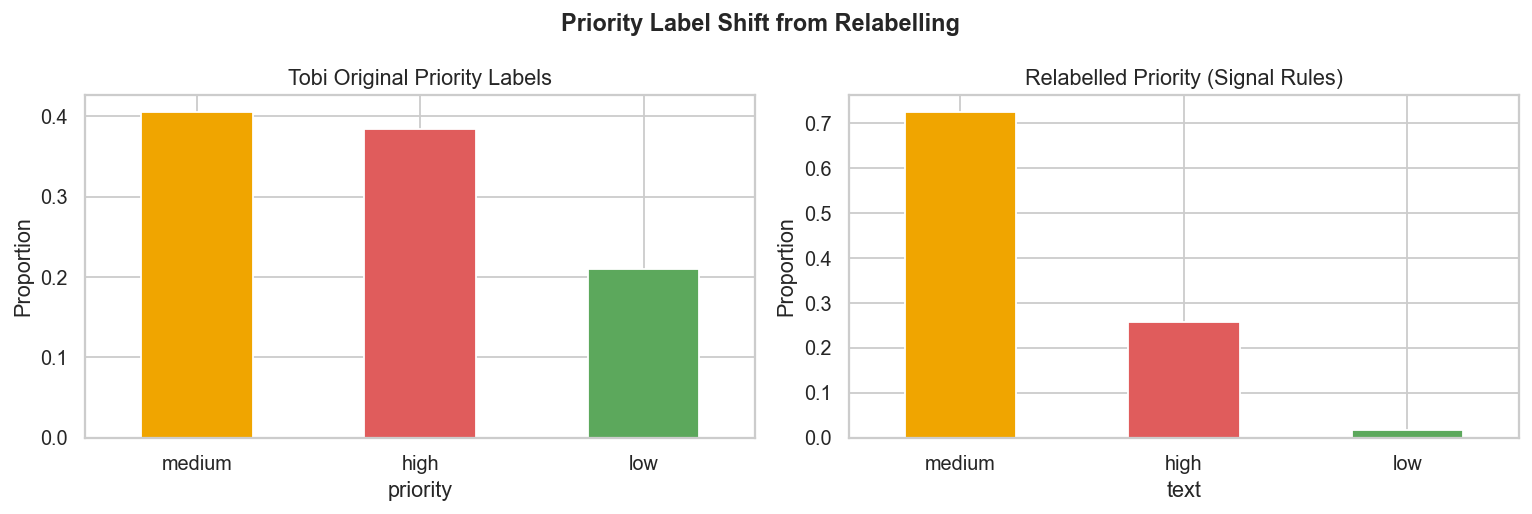

Note: relabelling will run on filtered data only — shown here for preview.

Relabelled distribution preview:
text
medium    0.726
high      0.258
low       0.016
Name: proportion, dtype: float64


In [20]:
HIGH_SIGNALS = [
    r'\b(urgent|critical|emergency|immediately|asap|as soon as possible)\b',
    r'\b(cannot|can\'t|unable to).{0,20}\b(access|login|work|function|process)\b',
    r'\b(production|system|server).{0,20}\b(down|crash|fail|failure)\b',
    r'\b(all users?|everyone|entire|company.wide|office.wide)\b',
    r'\b(data (loss|breach|corruption|leak))\b',
    r'\b(security|breach|hack|compromised|unauthorized access)\b',
    r'\b(multiple|several|many).{0,20}\b(users?|customers?|employees?|departments?)\b',
    r'\b(deadline|time.sensitive|time.critical|sla|sla breach)\b',
    r'\b(revenue|business).{0,20}\b(impact|affected|loss|disruption)\b',
]

LOW_SIGNALS = [
    r'\b(question|wondering|curious|just wanted to)\b',
    r'\b(when (you have|possible|convenient)|no rush|whenever)\b',
    r'\b(would like to know|could you (tell|explain|clarify|provide))\b',
    r'\b(documentation|brochure|information about|learn more|find out)\b',
    r'\b(considering|thinking about|planning to|in the future|eventually)\b',
    r'\b(general|just checking|quick question|minor|small issue)\b',
    r'\b(when (you get|you have) a chance|at your convenience)\b',
]

def relabel_priority(text: str) -> str:
    """
    Relabel priority from signal rules aligned with Priority_Escalation_Criteria.txt.
    Uses threshold of 1 for high (easier to trigger), 2 for low.
    Most tickets default to medium — that's expected.
    """
    text_lower = text.lower()
    high_hits = sum(1 for p in HIGH_SIGNALS if re.search(p, text_lower))
    low_hits  = sum(1 for p in LOW_SIGNALS  if re.search(p, text_lower))
    # Lower threshold: 1 high signal = high priority
    # Avoids everything collapsing to medium
    if high_hits >= 1: return 'high'
    if low_hits >= 2:  return 'low'
    return 'medium'

# Preview: how much does relabelling change priority?
sample = df.sample(min(5000, len(df)), random_state=SEED)
original_pri   = sample['priority'].value_counts(normalize=True)
relabelled_pri = sample['text'].apply(relabel_priority).value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
original_pri.plot(kind='bar', ax=axes[0], color=[PALETTE_PRI.get(k,'grey') for k in original_pri.index])
axes[0].set_title('Tobi Original Priority Labels')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)

relabelled_pri.plot(kind='bar', ax=axes[1], color=[PALETTE_PRI.get(k,'grey') for k in relabelled_pri.index])
axes[1].set_title('Relabelled Priority (Signal Rules)')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Priority Label Shift from Relabelling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: relabelling will run on filtered data only — shown here for preview.')
print(f'\nRelabelled distribution preview:')
print(relabelled_pri.round(3))


## 5. Run Full Filter Pipeline

In [21]:
SMALL_CLASSES = {
    'General Inquiry', 'Human Resources',
    'Sales and Pre-Sales', 'Returns and Exchanges'
}

def score_ticket(row) -> dict | None:
    text  = str(row['text'])
    label = str(row['queue'])

    # ── HARD FILTERS (any fail = drop) ────────────────────────────────────

    # 1. Length
    word_count = len(text.split())
    if not (15 <= word_count <= 350):
        return None

    # 2. Template skeleton
    if is_template_skeleton(text):
        return None

    # 3. Label coherence — strict for large classes, relaxed for small ones
    #    Small classes have generically-written tickets so fewer anchor hits
    coherence = label_coherence_score(text, label)
    min_coherence = 0 if label in SMALL_CLASSES else 1
    if coherence < min_coherence:
        return None

    # ── SOFT FILTERS (need at least 2 of 3) ───────────────────────────────
    specificity = has_specificity(text)
    human       = sounds_human(text)
    density     = content_density(text) >= 0.42

    soft_score = sum([specificity, human, density])

    # Small classes get 1 soft signal pass (they're already scarce)
    min_soft = 1 if label in SMALL_CLASSES else 2
    if soft_score < min_soft:
        return None

    # ── RELABEL PRIORITY ───────────────────────────────────────────────────
    new_priority = relabel_priority(text)

    return {
        'text':           text,
        'queue':          label,
        'priority':       new_priority,
        'original_priority': str(row['priority']),
        'quality_score':  soft_score,
        'word_count':     word_count,
        'template_hits':  template_hit_count(text),
        'coherence_hits': coherence,
    }


print('Running filter pipeline...')
# Reset index so results list indices align with df row indices
df = df.reset_index(drop=True)
results = [score_ticket(row) for _, row in df.iterrows()]
df_filtered = pd.DataFrame([r for r in results if r is not None]).reset_index(drop=True)

# Dedup on normalised text
df_filtered['_norm'] = df_filtered['text'].str.lower().str.strip()
df_filtered = df_filtered.drop_duplicates(subset=['_norm']).drop(columns=['_norm'])

print(f'\n{"─"*45}')
print(f'  Raw English rows   : {len(df):>7,}')
print(f'  Survived filters   : {len(df_filtered):>7,}  ({len(df_filtered)/len(df)*100:.1f}%)')
print(f'  Dropped            : {len(df)-len(df_filtered):>7,}')
print(f'{"─"*45}')
print(f'\nPer class after filtering:')
print(df_filtered['queue'].value_counts())


Running filter pipeline...

─────────────────────────────────────────────
  Raw English rows   :  28,261
  Survived filters   :   6,921  (24.5%)
  Dropped            :  21,340
─────────────────────────────────────────────

Per class after filtering:
queue
Technical & IT Support             3471
Returns and Exchanges              1038
Billing and Payments                680
Sales and Pre-Sales                 635
Human Resources                     396
General Inquiry                     309
Customer Service                    237
Service Outages and Maintenance     155
Name: count, dtype: int64


## 6. Class Distribution After Filtering

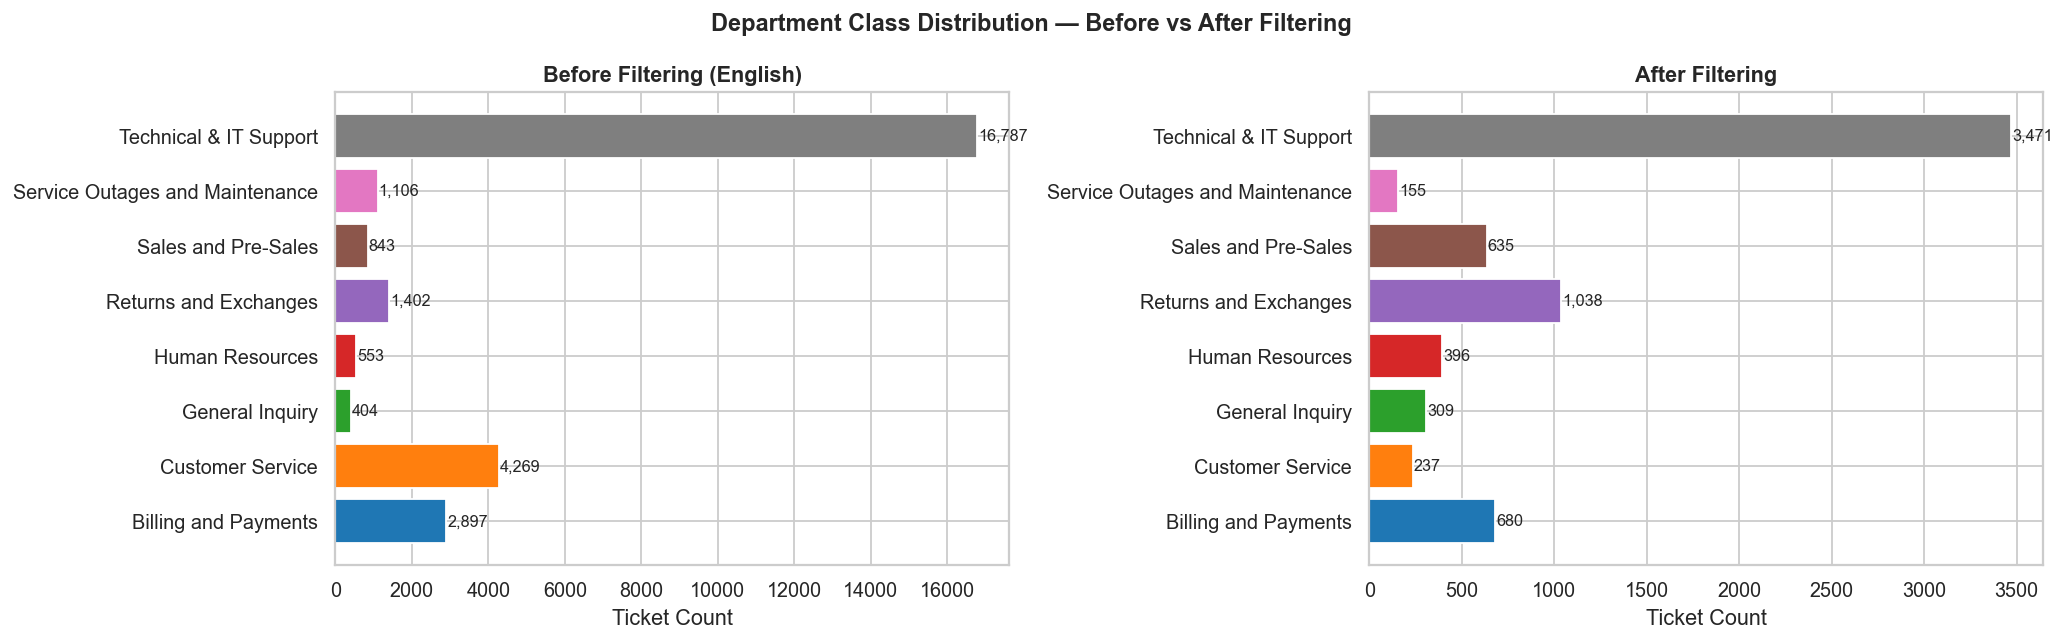

                                 Before  After  Retention %
queue                                                      
Billing and Payments               2897    680         23.5
Customer Service                   4269    237          5.6
General Inquiry                     404    309         76.5
Human Resources                     553    396         71.6
Returns and Exchanges              1402   1038         74.0
Sales and Pre-Sales                 843    635         75.3
Service Outages and Maintenance    1106    155         14.0
Technical & IT Support            16787   3471         20.7


In [22]:
counts_filtered = df_filtered['queue'].value_counts().reindex(DEPT_ORDER, fill_value=0)
counts_original = df['queue'].value_counts().reindex(DEPT_ORDER, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
bars0 = axes[0].barh(counts_original.index, counts_original.values,
                     color=PALETTE_DEPT, edgecolor='white')
axes[0].set_title('Before Filtering (English)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ticket Count')
for bar, val in zip(bars0, counts_original.values):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# After
bars1 = axes[1].barh(counts_filtered.index, counts_filtered.values,
                     color=PALETTE_DEPT, edgecolor='white')
axes[1].set_title('After Filtering', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ticket Count')
for bar, val in zip(bars1, counts_filtered.values):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

plt.suptitle('Department Class Distribution — Before vs After Filtering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Before': counts_original,
    'After':  counts_filtered,
    'Retention %': (counts_filtered / counts_original * 100).round(1),
})
print(summary.to_string())

## 7. Class Balancing

In [23]:
# ── Strategy ──────────────────────────────────────────────────────────────
# - Cap large classes at MAX_PER_CLASS (take highest quality_score tickets)
# - Accept small classes as-is (real > synthetic padding)
# - Flag any class with < MIN_VIABLE as a warning

MAX_PER_CLASS = 700
MIN_VIABLE    = 150

balanced_parts = []

for dept in DEPT_ORDER:
    subset = df_filtered[df_filtered['queue'] == dept].copy()
    n = len(subset)

    if n == 0:
        print(f'  ⚠️  {dept:<40} — 0 tickets survived — CANNOT TRAIN')
        continue
    elif n < MIN_VIABLE:
        print(f'  ⚠️  {dept:<40} — only {n} tickets (below {MIN_VIABLE} — low confidence class)')
        balanced_parts.append(subset)
    elif n > MAX_PER_CLASS:
        # Take top quality tickets first
        subset_sorted = subset.sort_values(
            ['quality_score', 'coherence_hits'], ascending=False
        )
        balanced_parts.append(subset_sorted.head(MAX_PER_CLASS))
        print(f'  ✓  {dept:<40} — capped {n} → {MAX_PER_CLASS}')
    else:
        balanced_parts.append(subset)
        print(f'  ✓  {dept:<40} — kept all {n}')

df_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'\nFinal balanced dataset: {len(df_balanced):,} tickets')
print(f'Classes: {df_balanced["queue"].nunique()}')

  ✓  Billing and Payments                     — kept all 680
  ✓  Customer Service                         — kept all 237
  ✓  General Inquiry                          — kept all 309
  ✓  Human Resources                          — kept all 396
  ✓  Returns and Exchanges                    — capped 1038 → 700
  ✓  Sales and Pre-Sales                      — kept all 635
  ✓  Service Outages and Maintenance          — kept all 155
  ✓  Technical & IT Support                   — capped 3471 → 700

Final balanced dataset: 3,812 tickets
Classes: 8


## 8. Quality Score Distribution

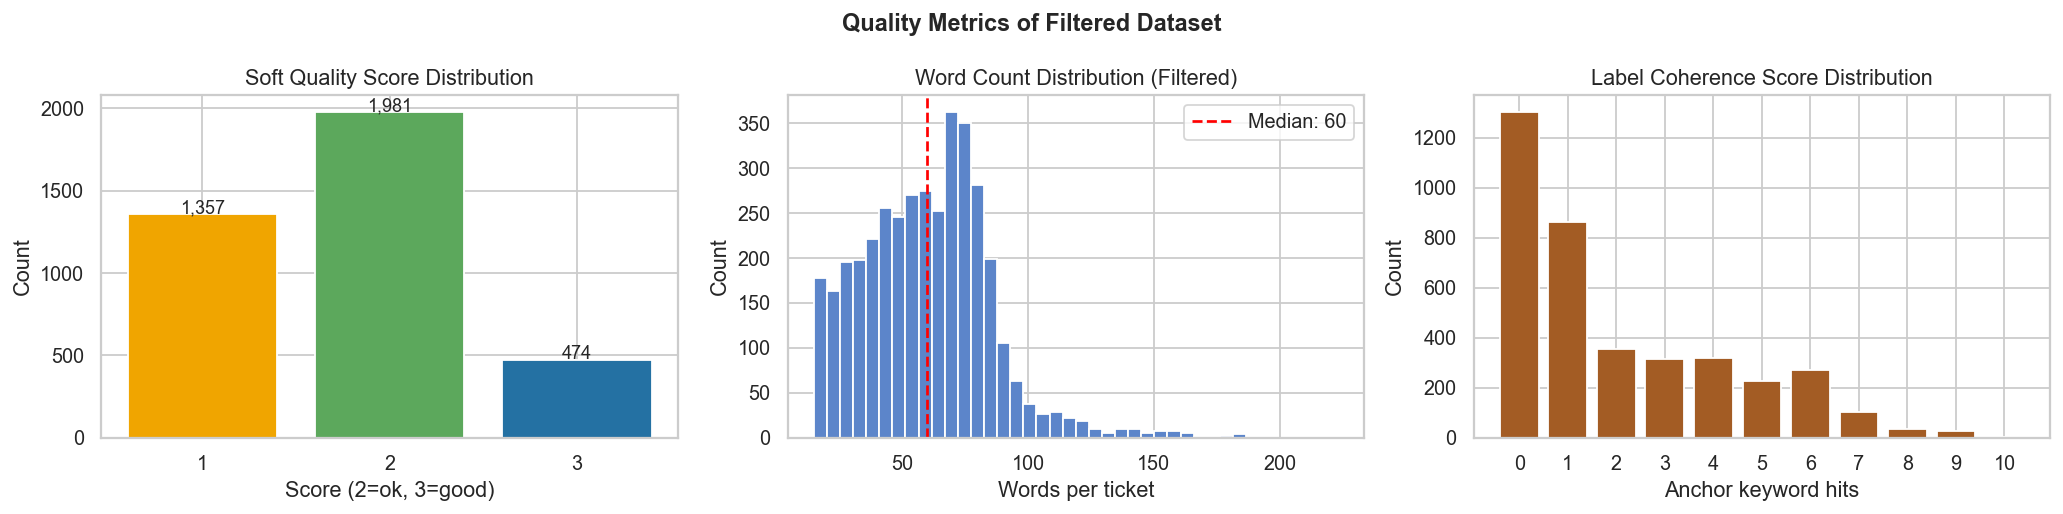

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Quality score distribution
score_counts = df_balanced['quality_score'].value_counts().sort_index()
axes[0].bar(score_counts.index.astype(str), score_counts.values,
            color=['#f0a500','#5ca85c','#2471a3'])
axes[0].set_title('Soft Quality Score Distribution')
axes[0].set_xlabel('Score (2=ok, 3=good)')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(score_counts.items()):
    axes[0].text(i, val + 5, f'{val:,}', ha='center', fontsize=10)

# Word count distribution
axes[1].hist(df_balanced['word_count'], bins=40, color='#5c85ca', edgecolor='white')
axes[1].set_title('Word Count Distribution (Filtered)')
axes[1].set_xlabel('Words per ticket')
axes[1].set_ylabel('Count')
axes[1].axvline(df_balanced['word_count'].median(), color='red',
                linestyle='--', label=f"Median: {df_balanced['word_count'].median():.0f}")
axes[1].legend()

# Coherence hits distribution
coh_counts = df_balanced['coherence_hits'].value_counts().sort_index()
axes[2].bar(coh_counts.index.astype(str), coh_counts.values, color='#a35c24')
axes[2].set_title('Label Coherence Score Distribution')
axes[2].set_xlabel('Anchor keyword hits')
axes[2].set_ylabel('Count')

plt.suptitle('Quality Metrics of Filtered Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Final Dataset — Full Visual Analysis

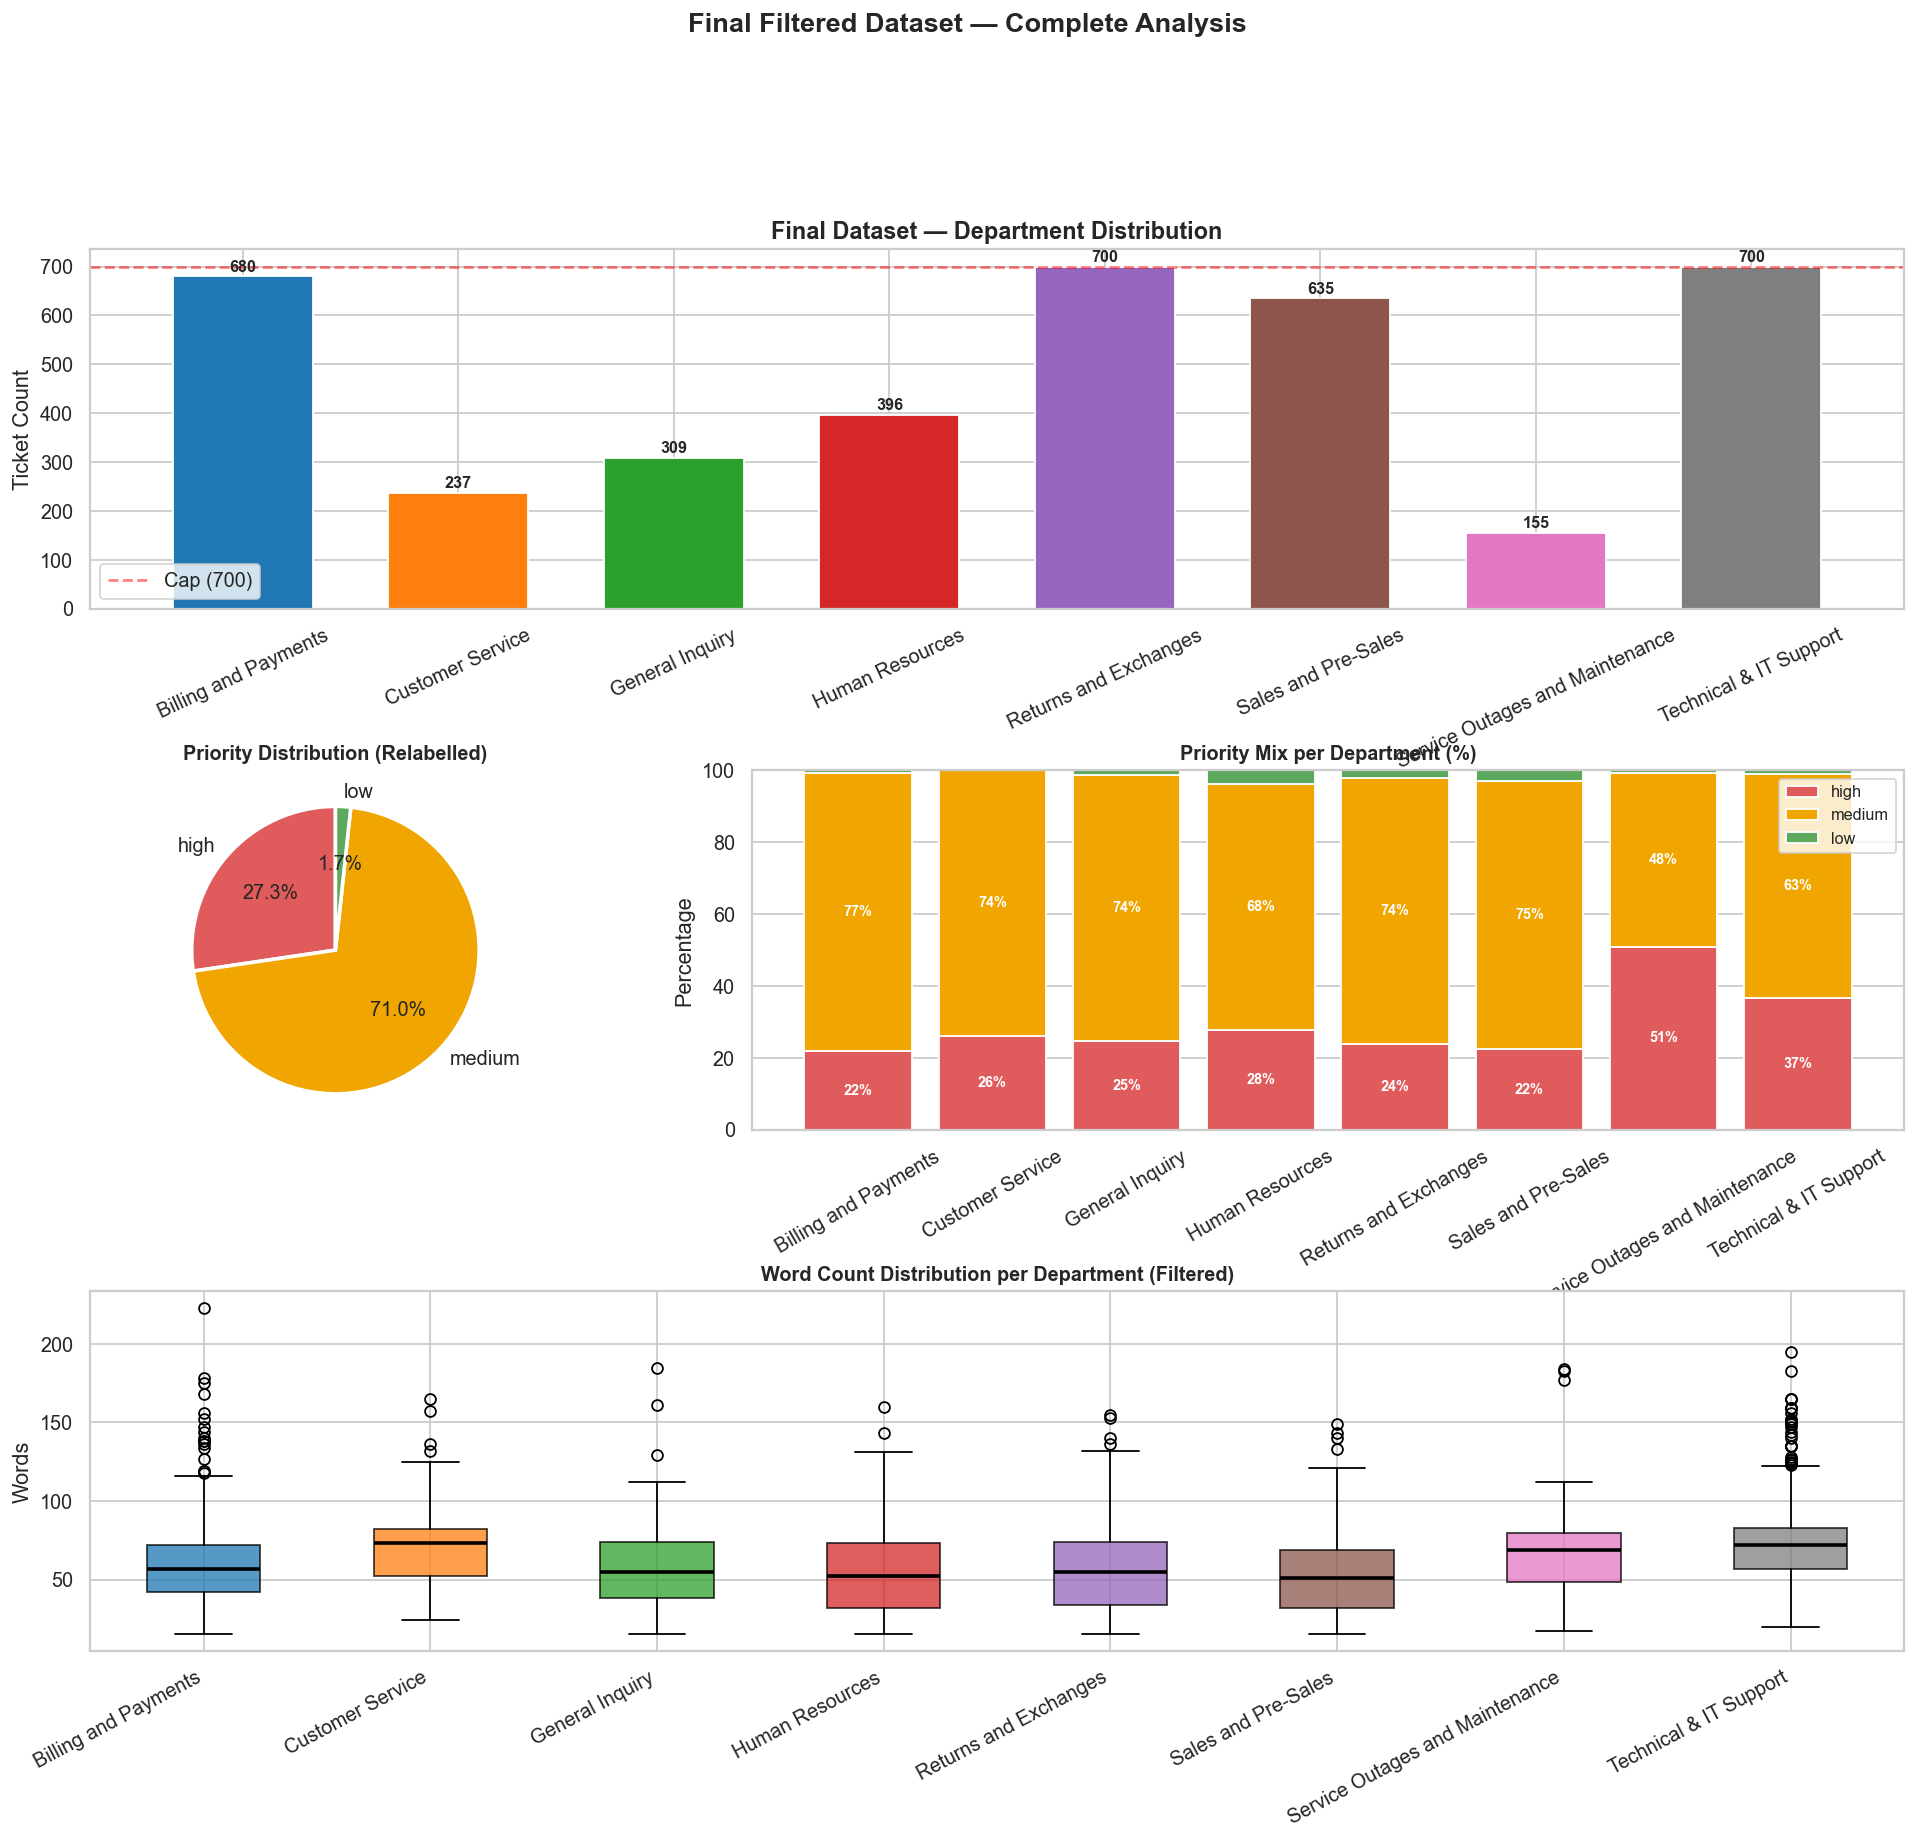

Saved → outputs/dataset_analysis.png


In [25]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

counts_bal = df_balanced['queue'].value_counts().reindex(DEPT_ORDER, fill_value=0)

# ── Plot 1: Department bar chart ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.bar(counts_bal.index, counts_bal.values,
               color=PALETTE_DEPT, edgecolor='white', width=0.65)
ax1.set_title('Final Dataset — Department Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Ticket Count')
ax1.tick_params(axis='x', rotation=25)
for bar, val in zip(bars, counts_bal.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.axhline(MAX_PER_CLASS, color='red', linestyle='--', alpha=0.5, label=f'Cap ({MAX_PER_CLASS})')
ax1.legend()

# ── Plot 2: Priority distribution overall ─────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
pri_counts = df_balanced['priority'].value_counts().reindex(PRIORITY_ORDER, fill_value=0)
ax2.pie(
    pri_counts.values,
    labels=pri_counts.index,
    autopct='%1.1f%%',
    colors=[PALETTE_PRI[k] for k in pri_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
ax2.set_title('Priority Distribution (Relabelled)', fontsize=11, fontweight='bold')

# ── Plot 3: Priority per department stacked bar ────────────────────────────
ax3 = fig.add_subplot(gs[1, 1:])
pri_dept = (
    df_balanced.groupby(['queue', 'priority'])
    .size()
    .unstack(fill_value=0)
    .reindex(DEPT_ORDER, fill_value=0)
    .reindex(columns=PRIORITY_ORDER, fill_value=0)
)
pri_dept_pct = pri_dept.div(pri_dept.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(pri_dept_pct))
for pri in PRIORITY_ORDER:
    vals = pri_dept_pct[pri].values
    bars3 = ax3.bar(pri_dept_pct.index, vals, bottom=bottom,
                    label=pri, color=PALETTE_PRI[pri], edgecolor='white')
    for i, (bar, val) in enumerate(zip(bars3, vals)):
        if val > 8:
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bottom[i] + val/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bottom += vals
ax3.set_title('Priority Mix per Department (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Percentage')
ax3.tick_params(axis='x', rotation=30)
ax3.legend(loc='upper right', fontsize=9)

# ── Plot 4: Word count box plot per department ─────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
dept_wc_data = [df_balanced[df_balanced['queue']==d]['word_count'].values for d in DEPT_ORDER]
bp = ax4.boxplot(dept_wc_data, patch_artist=True, notch=False,
                 medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE_DEPT):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax4.set_xticklabels(DEPT_ORDER, rotation=28, ha='right')
ax4.set_title('Word Count Distribution per Department (Filtered)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Words')

plt.suptitle('Final Filtered Dataset — Complete Analysis', fontsize=15, fontweight='bold', y=1.01)
import os
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/dataset_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → outputs/dataset_analysis.png')

## 10. Priority Label Agreement — Original vs Relabelled

Priority label agreement (Tobi vs relabelled): 1,548/3,812 (40.6%)
Disagreement (relabelled):                      2,264 (59.4%)


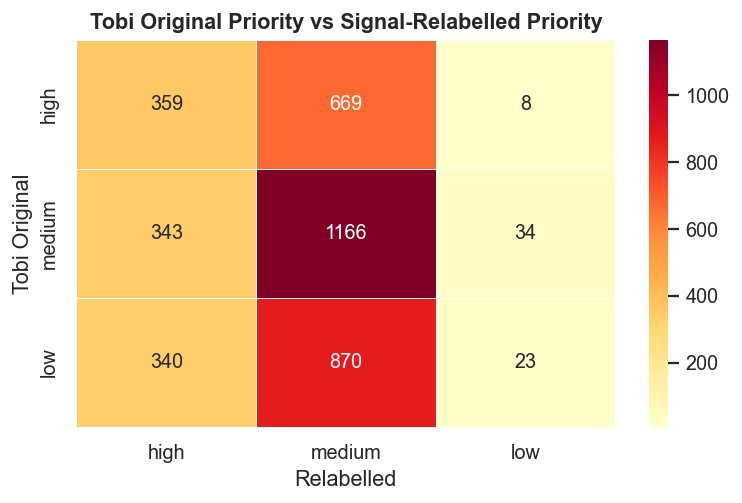

Saved → priority_relabel_heatmap.png


In [26]:
import os
os.makedirs('outputs', exist_ok=True)
agree = (df_balanced['priority'] == df_balanced['original_priority']).sum()
total = len(df_balanced)
print(f'Priority label agreement (Tobi vs relabelled): {agree:,}/{total:,} ({agree/total*100:.1f}%)')
print(f'Disagreement (relabelled):                      {total-agree:,} ({(total-agree)/total*100:.1f}%)')

# Cross-tab of original vs relabelled
cross = pd.crosstab(
    df_balanced['original_priority'],
    df_balanced['priority'],
    rownames=['Tobi Original'],
    colnames=['Relabelled']
).reindex(index=PRIORITY_ORDER, columns=PRIORITY_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Tobi Original Priority vs Signal-Relabelled Priority', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/priority_relabel_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → priority_relabel_heatmap.png')

## 11. Sample Tickets — Before and After (sanity check)

In [27]:
print('=' * 70)
print('SAMPLE TICKETS THAT SURVIVED FILTERING (top quality_score=3)')
print('=' * 70)

top_quality = df_balanced[df_balanced['quality_score'] == 3].sample(
    min(6, len(df_balanced[df_balanced['quality_score']==3])), random_state=SEED
)

for i, (_, row) in enumerate(top_quality.iterrows()):
    print(f'\n[{i+1}] Dept: {row["queue"]} | Priority: {row["priority"]} '
          f'(was: {row["original_priority"]}) | Words: {row["word_count"]} '
          f'| Coherence: {row["coherence_hits"]}')
    print('-' * 60)
    print(row['text'][:400])
    if len(row['text']) > 400:
        print('...')

print('\n' + '=' * 70)
print('EXAMPLE TICKETS THAT WERE DROPPED (template skeleton sample)')
print('=' * 70)

# Build a boolean mask aligned to df (which is now reset_index'd)
dropped_mask = pd.Series([r is None for r in results], index=df.index)
dropped_indices = dropped_mask[dropped_mask].index.tolist()

if dropped_indices:
    sample_n = min(3, len(dropped_indices))
    sampled_indices = pd.Series(dropped_indices).sample(sample_n, random_state=SEED).tolist()
    for i, idx in enumerate(sampled_indices):
        text = df.loc[idx, 'text']
        print(f'\n[DROPPED {i+1}]')
        print('-' * 60)
        print(text[:350])
        if len(text) > 350:
            print('...')
else:
    print("No dropped tickets to show.")


SAMPLE TICKETS THAT SURVIVED FILTERING (top quality_score=3)

[1] Dept: Technical & IT Support | Priority: high (was: high) | Words: 57 | Coherence: 4
------------------------------------------------------------
There was an unexpected downtime for the project management SaaS platform, which affected user access. It may have been caused by server configuration errors due to recent updates. I attempted to restart the affected services and reverted the latest configuration changes, but the issue still persists. Please assist us in resolving this matter as soon as possible.

[2] Dept: Technical & IT Support | Priority: high (was: high) | Words: 105 | Coherence: 4
------------------------------------------------------------
May I inform you about the unexpected crash of our investment analytics platform that occurred last night? Our team is unable to access essential data, and we believe the problem could be due to a recent RAID-Controller update that may be incompatible. So far, we have a

## 12. Train / Val / Test Split

Train : 2,668 (70%)
Val   : 572  (15%)
Test  : 572  (15%)


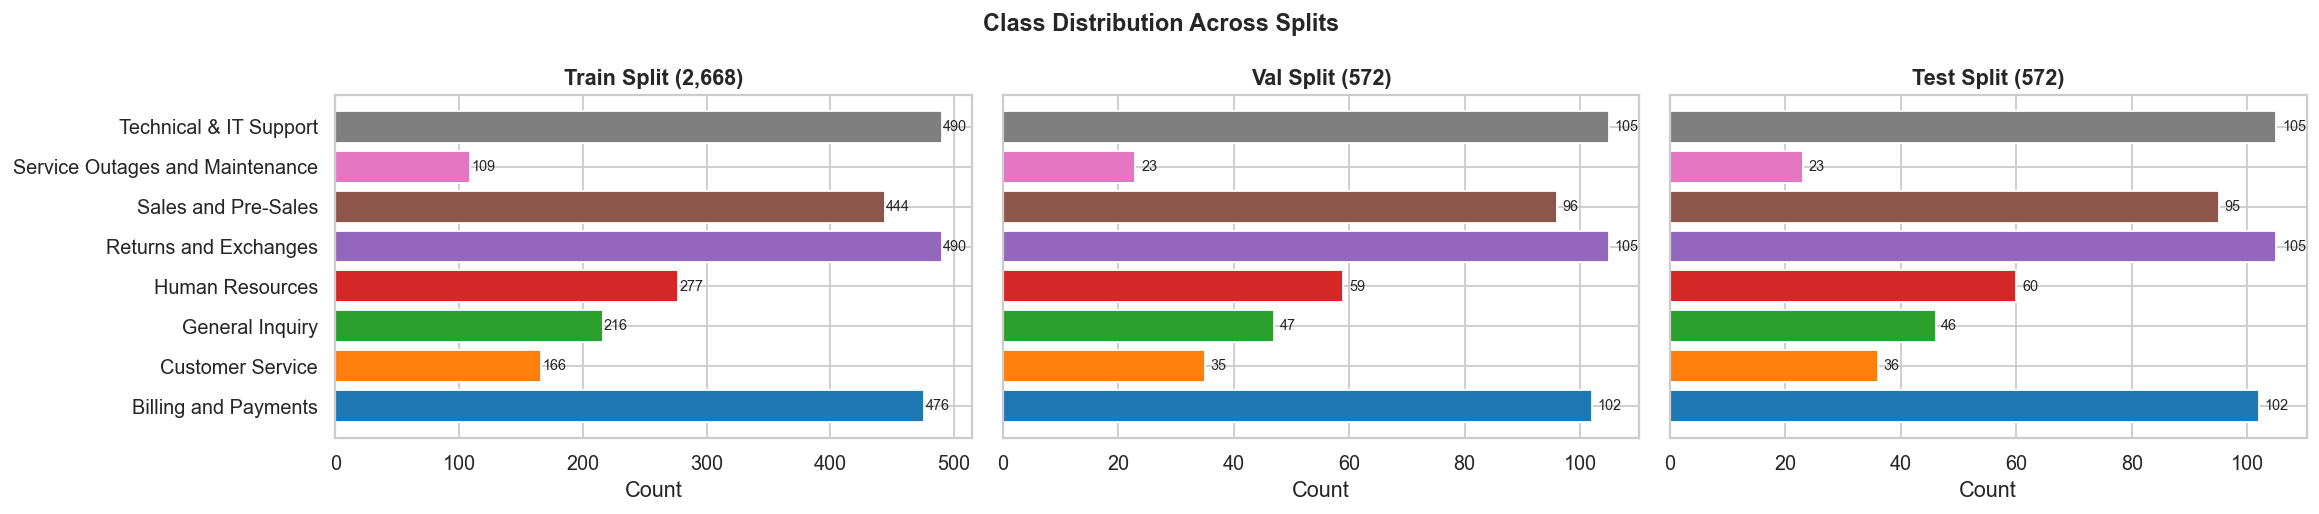

In [28]:
import os
os.makedirs('outputs', exist_ok=True)
# Stratify by dept so all splits have same class ratio
df_train, df_temp = train_test_split(
    df_balanced, test_size=0.30, random_state=SEED, stratify=df_balanced['queue']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['queue']
)

print(f'Train : {len(df_train):,} ({len(df_train)/len(df_balanced)*100:.0f}%)')
print(f'Val   : {len(df_val):,}  ({len(df_val)/len(df_balanced)*100:.0f}%)')
print(f'Test  : {len(df_test):,}  ({len(df_test)/len(df_balanced)*100:.0f}%)')

# Verify stratification held
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (split_name, split_df) in zip(axes, [('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    counts = split_df['queue'].value_counts().reindex(DEPT_ORDER, fill_value=0)
    ax.barh(counts.index, counts.values, color=PALETTE_DEPT, edgecolor='white')
    ax.set_title(f'{split_name} Split ({len(split_df):,})', fontweight='bold')
    ax.set_xlabel('Count')
    for i, val in enumerate(counts.values):
        ax.text(val + 1, i, str(val), va='center', fontsize=8)

plt.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/split_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 13. Export

In [29]:
import os
os.makedirs('outputs', exist_ok=True)
COLS = ['text', 'queue', 'priority', 'original_priority', 'quality_score', 'word_count']

df_train[COLS].to_csv('outputs/train_filtered.csv', index=False)
df_val[COLS].to_csv('outputs/val_filtered.csv',   index=False)
df_test[COLS].to_csv('outputs/test_filtered.csv',  index=False)
df_balanced[COLS].to_csv('outputs/full_filtered.csv', index=False)

print('Exported:')
print('  train_filtered.csv')
print('  val_filtered.csv')
print('  test_filtered.csv')
print('  full_filtered.csv')

print(f'\n{"─"*45}')
print(f'  Final balanced total : {len(df_balanced):>6,}')
print(f'  Train                : {len(df_train):>6,}')
print(f'  Val                  : {len(df_val):>6,}')
print(f'  Test                 : {len(df_test):>6,}')
print(f'  Dept classes         : {df_balanced["queue"].nunique():>6}')
print(f'  Priority classes     : {df_balanced["priority"].nunique():>6}')
print(f'{"─"*45}')

Exported:
  train_filtered.csv
  val_filtered.csv
  test_filtered.csv
  full_filtered.csv

─────────────────────────────────────────────
  Final balanced total :  3,812
  Train                :  2,668
  Val                  :    572
  Test                 :    572
  Dept classes         :      8
  Priority classes     :      3
─────────────────────────────────────────────


## 14. Final Summary Stats

In [30]:
print('\nFINAL DATASET SUMMARY')
print('=' * 55)

summary_final = df_balanced.groupby('queue').agg(
    count=('text', 'count'),
    avg_words=('word_count', 'mean'),
    avg_quality=('quality_score', 'mean'),
    avg_coherence=('coherence_hits', 'mean'),
    pct_high=('priority', lambda x: (x=='high').mean()*100),
    pct_medium=('priority', lambda x: (x=='medium').mean()*100),
    pct_low=('priority', lambda x: (x=='low').mean()*100),
).round(1).reindex(DEPT_ORDER)

print(summary_final.to_string())
print('=' * 55)

imbalance_ratio = counts_bal.max() / max(counts_bal.min(), 1)
print(f'\nImbalance ratio (max/min class): {imbalance_ratio:.1f}x')
print(f'(was {counts_original.max()/max(counts_original.min(),1):.1f}x before filtering)')


FINAL DATASET SUMMARY
                                 count  avg_words  avg_quality  avg_coherence  pct_high  pct_medium  pct_low
queue                                                                                                       
Billing and Payments               680       58.7          2.1            3.6      21.9        77.4      0.7
Customer Service                   237       69.5          2.1            1.0      26.2        73.8      0.0
General Inquiry                    309       55.9          1.4            0.4      24.6        74.1      1.3
Human Resources                    396       53.9          1.3            0.5      27.8        68.4      3.8
Returns and Exchanges              700       55.4          1.5            0.5      24.0        73.9      2.1
Sales and Pre-Sales                635       51.6          1.2            0.6      22.4        74.6      3.0
Service Outages and Maintenance    155       65.7          2.1            1.9      51.0        48.4      